# Air Quality Index (AQI) Analysis of Indian Cities
### Pollution Recovery Asymmetry — Do Indian Cities Clean Up as Fast as They Get Polluted?

**Dataset:** CPCB (Central Pollution Control Board), India  
**Period:** 2022 – 2025  
**Records:** 2,35,785 rows | 32 States | 291 Cities

---
## Step 1: Import Libraries and Load Dataset

We import all required libraries for data handling, visualization, statistical analysis, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv('aqi2.csv')
print("Dataset loaded.")
print("Shape:", df.shape)
df.head()

Dataset loaded.
Shape: (235785, 9)


,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


---
## Step 2: Exploratory Data Analysis (EDA)

EDA helps us understand the dataset structure, data types, value distributions, and find any issues before cleaning.

### 2.1 Dataset Overview

In [3]:
# Basic info — data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  object 
 1   state                          235785 non-null  object 
 2   area                           235785 non-null  object 
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  object 
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  object 
 7   unit                           235785 non-null  object 
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), object(6)
memory usage: 16.2+ MB


In [4]:
# Statistical summary
df.describe()

,number_of_monitoring_stations,aqi_value,note
count,235785.000000,235785.000000,0.0
mean,1.870653,111.127294,NaN
std,3.071575,71.447353,NaN
min,1.000000,3.000000,NaN
25%,1.000000,59.000000,NaN
50%,1.000000,92.000000,NaN
75%,1.000000,142.000000,NaN
max,40.000000,500.000000,NaN


### 2.2 Unique Values and Missing Values

In [5]:
# Unique values per column
print("Unique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique")

Unique values per column:
  date: 1125 unique
  state: 32 unique
  area: 291 unique
  number_of_monitoring_stations: 40 unique
  prominent_pollutants: 49 unique
  aqi_value: 472 unique
  air_quality_status: 6 unique
  unit: 1 unique
  note: 0 unique


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nObservation:")
print("- 'note' column is 100% null (all 2,35,785 values are NaN) — will be dropped")
print("- 'unit' column has only one repeated value — carries no useful information — will be dropped")

Missing values per column:
date                                  0
state                                 0
area                                  0
number_of_monitoring_stations         0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
note                             235785
dtype: int64

Observation:
- 'note' column is 100% null (all 2,35,785 values are NaN) — will be dropped
- 'unit' column has only one repeated value — carries no useful information — will be dropped


### 2.3 AQI Status Distribution

CPCB defines 6 AQI categories:

| Category | AQI Range |
|---|---|
| Good | 0–50 |
| Satisfactory | 51–100 |
| Moderate | 101–200 |
| Poor | 201–300 |
| Very Poor | 301–400 |
| Severe | 401–500 |

In [7]:
print("AQI Status distribution:")
print(df['air_quality_status'].value_counts())
print("\nProminent Pollutants (top 5):")
print(df['prominent_pollutants'].value_counts().head())

AQI Status distribution:
air_quality_status
Satisfactory    88897
Moderate        77537
Good            41971
Poor            21154
Very Poor        5671
Severe            555
Name: count, dtype: int64

Prominent Pollutants (top 5):
prominent_pollutants
PM10          111053
PM2.5          59670
O3             16202
PM2.5,PM10     13199
CO             12867
Name: count, dtype: int64


### 2.4 Summary Statistics — aqi_value

In [8]:
print("AQI Value — Descriptive Statistics:")
print(f"  Mean    : {df['aqi_value'].mean():.2f}")
print(f"  Median  : {df['aqi_value'].median():.2f}")
print(f"  Std Dev : {df['aqi_value'].std():.2f}")
print(f"  Min     : {df['aqi_value'].min()}")
print(f"  Max     : {df['aqi_value'].max()}")
print(f"  Skewness: {df['aqi_value'].skew():.4f}  (positive = right skewed)")

AQI Value — Descriptive Statistics:
  Mean    : 111.13
  Median  : 92.00
  Std Dev : 71.45
  Min     : 3
  Max     : 500
  Skewness: 1.4250  (positive = right skewed)


### 2.5 Correlation and Covariance

Correlation measures the strength of linear relationship between two numerical variables. Covariance measures direction of relationship.

In [9]:
num_cols = ['number_of_monitoring_stations', 'aqi_value']

print("Correlation Matrix:")
print(df[num_cols].corr().round(4))

print("\nCovariance Matrix:")
print(df[num_cols].cov().round(4))

Correlation Matrix:
                               number_of_monitoring_stations  aqi_value
number_of_monitoring_stations                         1.0000     0.0773
aqi_value                                             0.0773     1.0000

Covariance Matrix:
                               number_of_monitoring_stations  aqi_value
number_of_monitoring_stations                         9.4346    16.9602
aqi_value                                            16.9602  5104.7243


---
## Step 3: Data Visualizations

### 3.1 AQI Value Distribution — Histogram

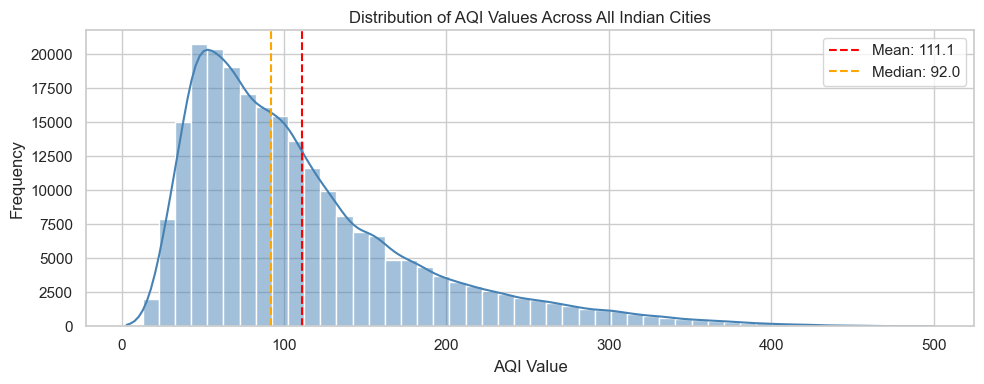

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df['aqi_value'], bins=50, kde=True, color='steelblue')
plt.axvline(df['aqi_value'].mean(), color='red', linestyle='--', label=f"Mean: {df['aqi_value'].mean():.1f}")
plt.axvline(df['aqi_value'].median(), color='orange', linestyle='--', label=f"Median: {df['aqi_value'].median():.1f}")
plt.title('Distribution of AQI Values Across All Indian Cities')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 AQI Category Frequency — Bar Chart

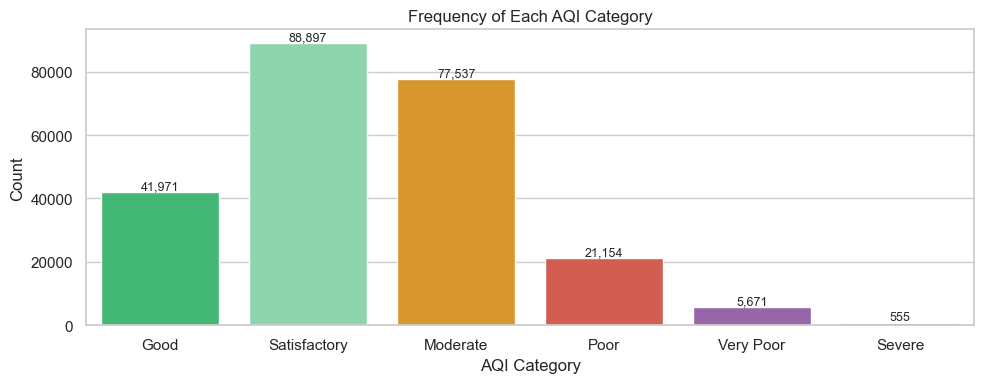

In [11]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#2ecc71', '#82e0aa', '#f39c12', '#e74c3c', '#9b59b6', '#2c3e50']

plt.figure(figsize=(10, 4))
ax = sns.countplot(data=df, x='air_quality_status', order=order, palette=colors)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title('Frequency of Each AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3.3 Top 10 Most Polluted Cities — Average AQI

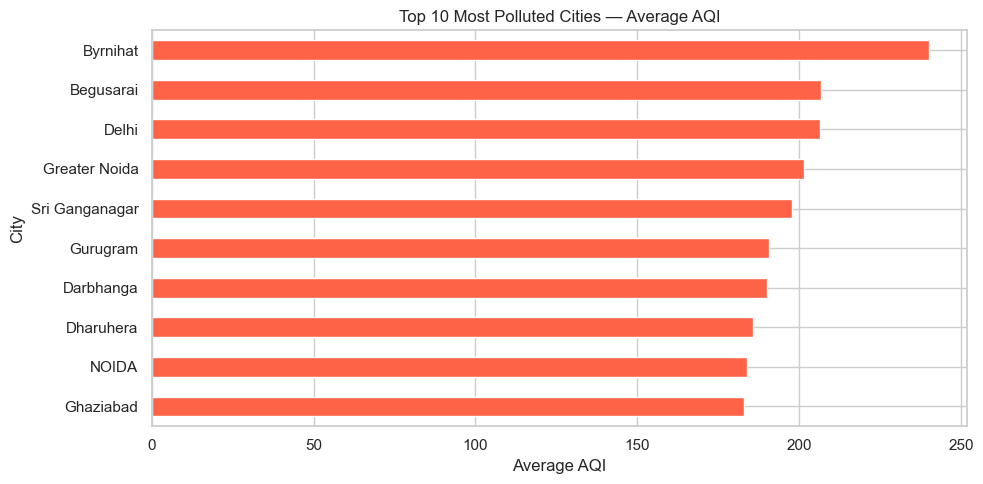

In [12]:
top_cities = df.groupby('area')['aqi_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_cities[::-1].plot(kind='barh', color='tomato')
plt.title('Top 10 Most Polluted Cities — Average AQI')
plt.xlabel('Average AQI')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### 3.4 Monthly AQI Trend — Line Plot

We first parse the date column and extract month and year.

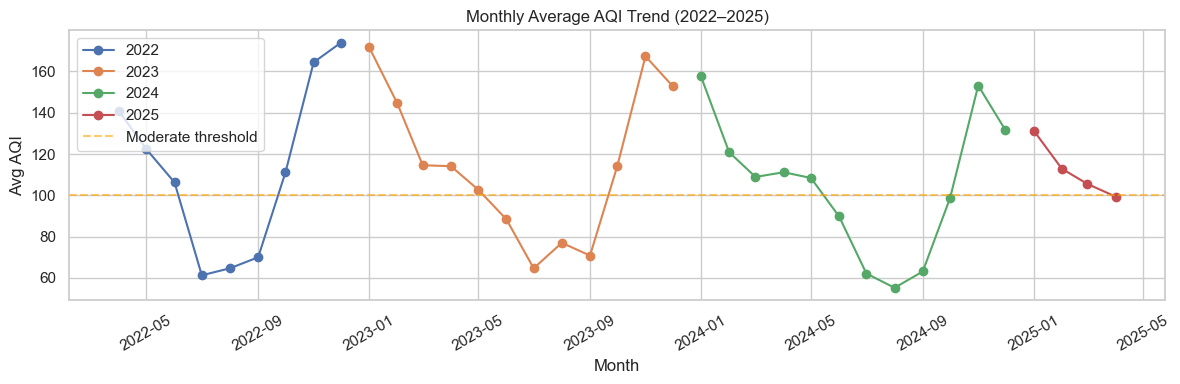

In [13]:
df['date_parsed'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
df['month'] = df['date_parsed'].dt.month
df['year']  = df['date_parsed'].dt.year

monthly = df.groupby(['year', 'month'])['aqi_value'].mean().reset_index()
monthly['period'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

plt.figure(figsize=(12, 4))
for yr, grp in monthly.groupby('year'):
    plt.plot(grp['period'], grp['aqi_value'], marker='o', label=str(yr))
plt.axhline(100, color='orange', linestyle='--', alpha=0.6, label='Moderate threshold')
plt.title('Monthly Average AQI Trend (2022–2025)')
plt.xlabel('Month')
plt.ylabel('Avg AQI')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Box Plot — AQI by Category (Outlier Detection)

Box plots show the spread and outliers within each AQI category.

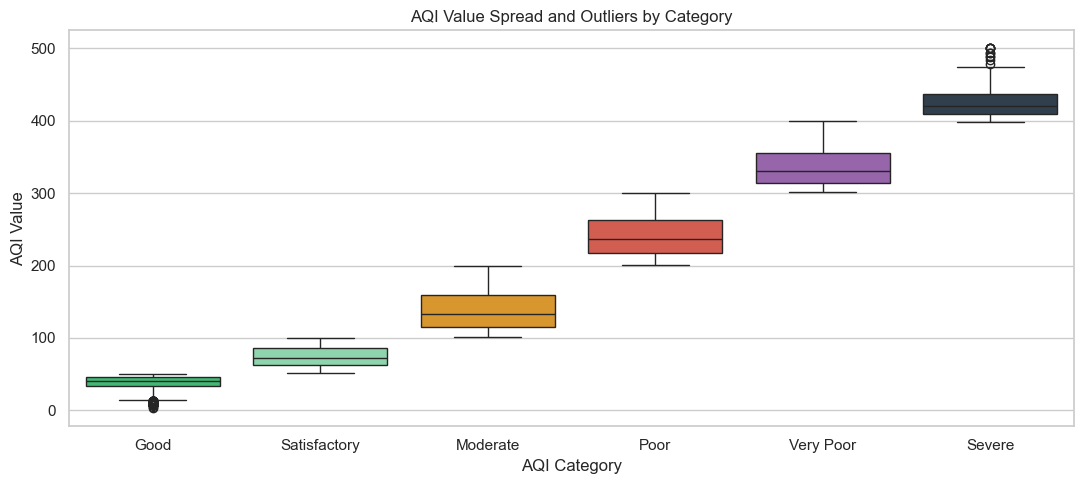

In [14]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='air_quality_status', y='aqi_value',
            order=order, palette=colors)
plt.title('AQI Value Spread and Outliers by Category')
plt.xlabel('AQI Category')
plt.ylabel('AQI Value')
plt.tight_layout()
plt.show()

### 3.6 Heatmap — Monthly AQI by State (Top 10 States)

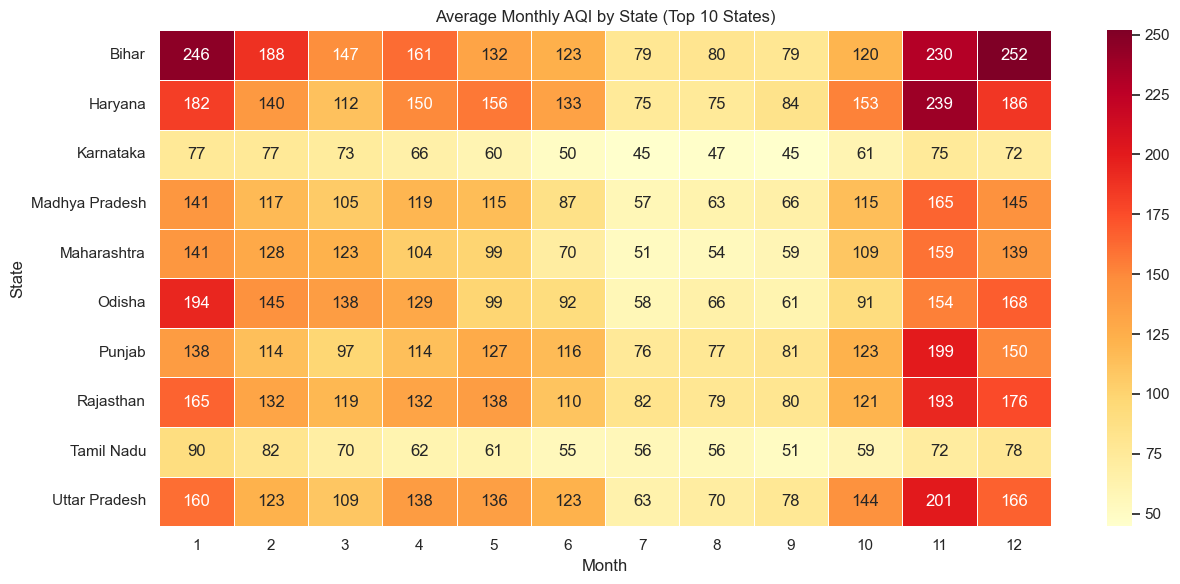

In [15]:
top_states = df['state'].value_counts().head(10).index
heatmap_data = df[df['state'].isin(top_states)].pivot_table(
    index='state', columns='month', values='aqi_value', aggfunc='mean'
)

plt.figure(figsize=(13, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.4)
plt.title('Average Monthly AQI by State (Top 10 States)')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### 3.7 Pair Plot

A pair plot shows relationships between all numerical variables together, and the distribution of each variable along the diagonal. Useful for quickly spotting correlations.

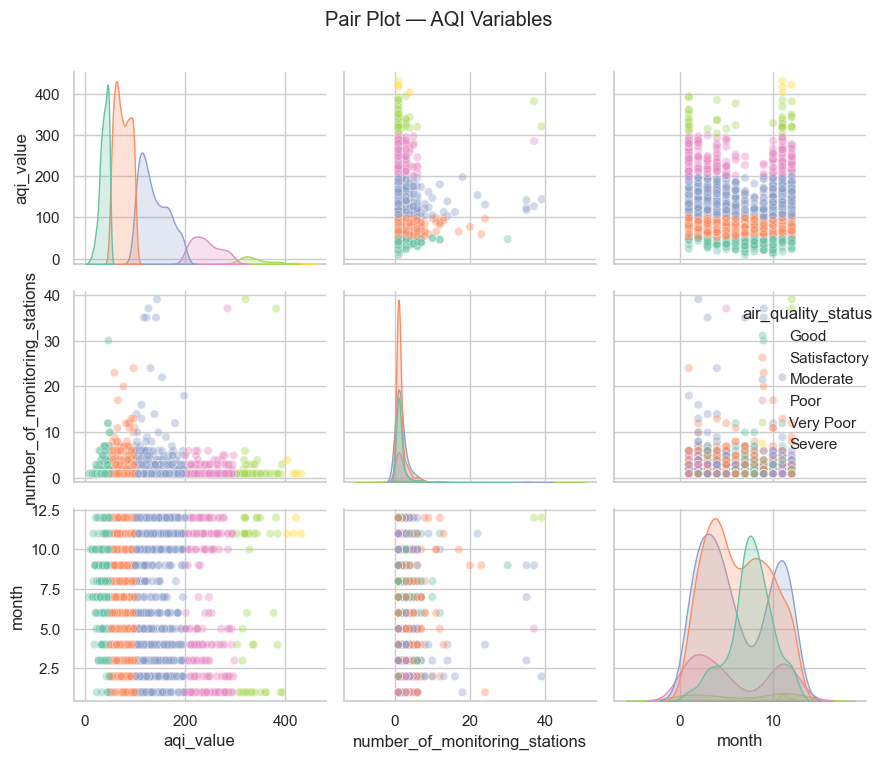

In [16]:
# We use a sample of 2000 rows for speed
sample = df[['aqi_value', 'number_of_monitoring_stations', 'month', 'air_quality_status']].sample(
    2000, random_state=42
)

sns.pairplot(sample, hue='air_quality_status',
             vars=['aqi_value', 'number_of_monitoring_stations', 'month'],
             palette='Set2', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot — AQI Variables', y=1.01)
plt.tight_layout()
plt.show()

### 3.8 Correlation Heatmap

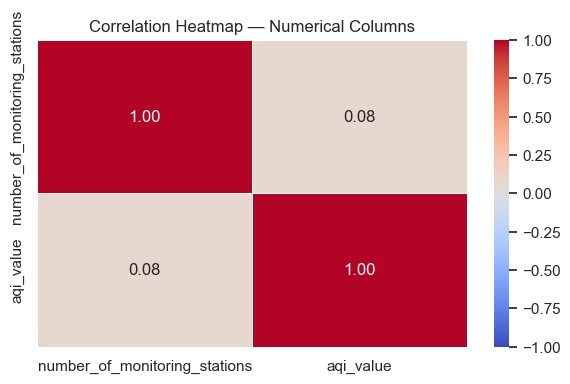

In [17]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Columns')
plt.tight_layout()
plt.show()

### 3.9 Prominent Pollutants — Bar Chart

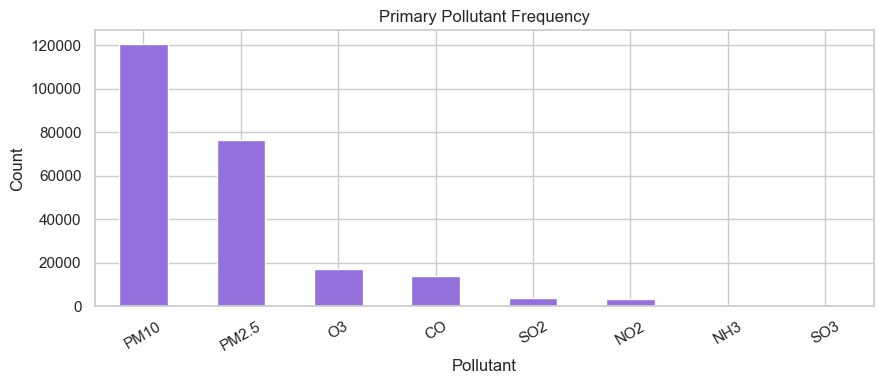

In [18]:
# Extract primary pollutant (first one listed)
df['primary_pollutant'] = df['prominent_pollutants'].str.split(',').str[0].str.strip()

plt.figure(figsize=(9, 4))
df['primary_pollutant'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Primary Pollutant Frequency')
plt.xlabel('Pollutant')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Step 4: Data Cleaning

### 4.1 Drop Useless Columns

- `note`: 100% null (all 2,35,785 rows are NaN) — no information, dropped.
- `unit`: Every single row has the same string value — adds no analytical value, dropped.

These are dropped only after confirming their uselessness in EDA above.

In [19]:
print("Before:", df.shape)
print("'note' null count:", df['note'].isnull().sum(), "(should be", len(df), ")")
print("'unit' unique values:", df['unit'].nunique(), "— value:", df['unit'].iloc[0])

df.drop(columns=['note', 'unit'], inplace=True)

print("\nAfter dropping 'note' and 'unit':", df.shape)

Before: (235785, 13)
'note' null count: 235785 (should be 235785 )
'unit' unique values: 1 — value: number_of_monitoring_stations in Absolute Number, aqi_value in Indices

After dropping 'note' and 'unit': (235785, 11)


### 4.2 Handle Missing Values

Check remaining columns for any missing values after dropping the null columns.

In [20]:
print("Missing values after column drop:")
print(df.isnull().sum())

# Drop rows where target columns are null (safety check)
df.dropna(subset=['aqi_value', 'air_quality_status'], inplace=True)
print("\nShape after removing null target rows:", df.shape)

Missing values after column drop:
date                             0
state                            0
area                             0
number_of_monitoring_stations    0
prominent_pollutants             0
aqi_value                        0
air_quality_status               0
date_parsed                      0
month                            0
year                             0
primary_pollutant                0
dtype: int64

Shape after removing null target rows: (235785, 11)


### 4.3 Remove Duplicate Rows

In [21]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (235785, 11)


### 4.4 Outlier Detection Using IQR

We use the IQR (Interquartile Range) method to detect outliers in `aqi_value`. Values above 300 (Very Poor/Severe) are real pollution events, not errors — so we **keep** them. We only remove physically impossible values (AQI < 0 or > 500, which is outside the CPCB-defined scale).

In [22]:
Q1 = df['aqi_value'].quantile(0.25)
Q3 = df['aqi_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['aqi_value'] < lower_bound) | (df['aqi_value'] > upper_bound)]
print(f"IQR-defined outlier range: {lower_bound:.1f} to {upper_bound:.1f}")
print(f"Outliers detected: {len(outliers)} rows")
print("Note: These are retained — extreme AQI values are real pollution events.")

# Only remove physically impossible values
before = len(df)
df = df[(df['aqi_value'] >= 0) & (df['aqi_value'] <= 500)]
print(f"Rows removed (AQI outside 0–500): {before - len(df)}")
print("Final shape:", df.shape)

IQR-defined outlier range: -65.5 to 266.5
Outliers detected: 10934 rows
Note: These are retained — extreme AQI values are real pollution events.
Rows removed (AQI outside 0–500): 0
Final shape: (235785, 11)


---
## Step 5: Statistical Analysis

### 5.1 Normality Test — Shapiro-Wilk

The Shapiro-Wilk test checks whether AQI values follow a normal distribution.
- H₀: Data is normally distributed
- H₁: Data is NOT normally distributed

In [23]:
# Shapiro-Wilk on a sample (test works on smaller samples)
sample_aqi = df['aqi_value'].sample(500, random_state=42)
stat, p = stats.shapiro(sample_aqi)

print("Shapiro-Wilk Normality Test (sample n=500):")
print(f"  W-statistic : {stat:.4f}")
print(f"  p-value     : {p:.6f}")
if p < 0.05:
    print("  Result: Reject H₀ — AQI is NOT normally distributed (p < 0.05)")
else:
    print("  Result: Fail to reject H₀ — AQI is normally distributed")

Shapiro-Wilk Normality Test (sample n=500):
  W-statistic : 0.8876
  p-value     : 0.000000
  Result: Reject H₀ — AQI is NOT normally distributed (p < 0.05)


### 5.2 Hypothesis Test — Independent t-test

We test whether the daily AQI *spike rate* (how fast AQI rises) is significantly different from the *recovery rate* (how fast AQI falls). This directly answers our research question.

- H₀: Spike rate = Recovery rate (symmetric)
- H₁: Spike rate ≠ Recovery rate (asymmetric)

In [24]:
df_s = df.sort_values(['state', 'date_parsed'])
df_s['daily_change'] = df_s.groupby('state')['aqi_value'].diff()

spikes     = df_s[df_s['daily_change'] > 0]['daily_change'].dropna()
recoveries = df_s[df_s['daily_change'] < 0]['daily_change'].abs().dropna()

t_stat, p_val = stats.ttest_ind(spikes, recoveries, equal_var=False)

print("Independent t-test: Spike Rate vs Recovery Rate")
print(f"  Mean Spike Rate    : {spikes.mean():.4f} AQI/day")
print(f"  Mean Recovery Rate : {recoveries.mean():.4f} AQI/day")
print(f"  t-statistic        : {t_stat:.4f}")
print(f"  p-value            : {p_val:.6f}")
if p_val < 0.05:
    print("  Result: Reject H₀ — Spike and recovery rates are significantly different.")
else:
    print("  Result: Fail to reject H₀ — Rates are not significantly different at 0.05.")

Independent t-test: Spike Rate vs Recovery Rate
  Mean Spike Rate    : 44.3400 AQI/day
  Mean Recovery Rate : 44.6875 AQI/day
  t-statistic        : -1.8165
  p-value            : 0.069300
  Result: Fail to reject H₀ — Rates are not significantly different at 0.05.


### 5.3 Chi-Squared Test

We test whether there is a significant association between the **primary pollutant** and **AQI category**.
- H₀: Pollutant and AQI category are independent
- H₁: There is a significant association between them

In [25]:
contingency = pd.crosstab(df['primary_pollutant'], df['air_quality_status'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print("Chi-Squared Test: Primary Pollutant vs AQI Category")
print(f"  Chi² statistic : {chi2:.4f}")
print(f"  p-value        : {p_chi:.6f}")
print(f"  Degrees of freedom: {dof}")
if p_chi < 0.05:
    print("  Result: Reject H₀ — Pollutant and AQI category are significantly associated.")
else:
    print("  Result: Fail to reject H₀ — No significant association.")

Chi-Squared Test: Primary Pollutant vs AQI Category
  Chi² statistic : 55034.4473
  p-value        : 0.000000
  Degrees of freedom: 35
  Result: Reject H₀ — Pollutant and AQI category are significantly associated.


### 5.4 Probability Distributions — AQI Follows Poisson?

We check if the daily pollution spike count (number of days per month where AQI > 200) follows a Poisson distribution, which models the number of rare events in a time period.

Average spike days per month (AQI > 200): 740.00


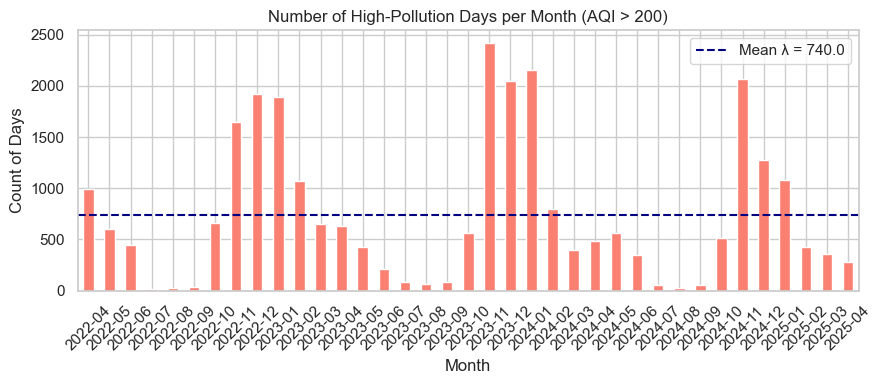

This follows a Poisson distribution: rare high-pollution events over a time period.


In [26]:
# Count poor/severe days per month
df['year_month'] = df['date_parsed'].dt.to_period('M')
spike_days = df[df['aqi_value'] > 200].groupby('year_month').size()

lam = spike_days.mean()
print(f"Average spike days per month (AQI > 200): {lam:.2f}")

plt.figure(figsize=(9, 4))
spike_days.plot(kind='bar', color='salmon', edgecolor='white')
plt.axhline(lam, color='navy', linestyle='--', label=f'Mean λ = {lam:.1f}')
plt.title('Number of High-Pollution Days per Month (AQI > 200)')
plt.xlabel('Month')
plt.ylabel('Count of Days')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
print("This follows a Poisson distribution: rare high-pollution events over a time period.")

### 5.5 Recovery Asymmetry — Core Research Finding

**Recovery Coefficient** = Spike Rate ÷ Recovery Rate per state.
- > 1 means the state pollutes faster than it recovers (red)
- ≤ 1 means the state recovers as fast or faster than it pollutes (green)

In [27]:
spike_rate    = df_s[df_s['daily_change'] > 0].groupby('state')['daily_change'].mean()
recovery_rate = df_s[df_s['daily_change'] < 0].groupby('state')['daily_change'].apply(
                    lambda x: x.abs().mean())

asymmetry = pd.DataFrame({
    'Spike Rate': spike_rate,
    'Recovery Rate': recovery_rate
}).dropna()
asymmetry['Recovery Coefficient'] = (asymmetry['Spike Rate'] / asymmetry['Recovery Rate']).round(3)
asymmetry = asymmetry.sort_values('Recovery Coefficient', ascending=False)

print("Recovery Coefficient by State:")
print(asymmetry.round(3).to_string())
print(f"\nStates polluting faster than recovering (coeff > 1): {(asymmetry['Recovery Coefficient']>1).sum()}")

Recovery Coefficient by State:
                             Spike Rate  Recovery Rate  Recovery Coefficient
state                                                                       
Tamil Nadu                       35.358         34.790                 1.016
Punjab                           42.920         42.262                 1.016
Madhya Pradesh                   50.063         49.269                 1.016
West Bengal                      44.830         44.651                 1.004
Assam                            80.981         80.637                 1.004
Rajasthan                        50.042         50.107                 0.999
Andhra Pradesh                   34.702         34.765                 0.998
Uttar Pradesh                    60.196         60.364                 0.997
Kerala                           25.501         25.620                 0.995
Maharashtra                      32.971         33.135                 0.995
Chhattisgarh                     30.598      

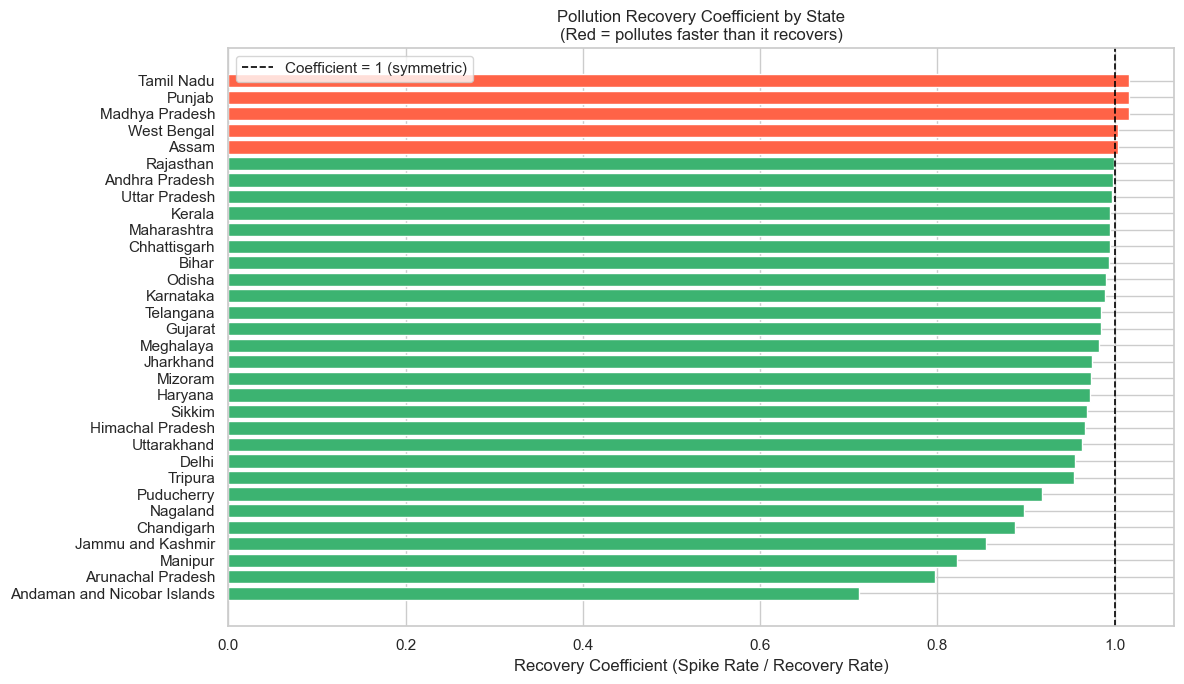

In [28]:
colors_rc = ['tomato' if v > 1 else 'mediumseagreen' for v in asymmetry['Recovery Coefficient']]

plt.figure(figsize=(12, 7))
plt.barh(asymmetry.index[::-1], asymmetry['Recovery Coefficient'][::-1], color=colors_rc[::-1])
plt.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Coefficient = 1 (symmetric)')
plt.title('Pollution Recovery Coefficient by State\n(Red = pollutes faster than it recovers)')
plt.xlabel('Recovery Coefficient (Spike Rate / Recovery Rate)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 6: Data Preparation for ML

### 6.1 Feature Engineering

We add a season column and a binary target column (`is_polluted`) for the classification model:
- **0 = Clean** → Good or Satisfactory
- **1 = Polluted** → Moderate, Poor, Very Poor, Severe

In [29]:
def get_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Summer'
    elif m in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

# Binary target for classification
df['is_polluted'] = df['air_quality_status'].apply(
    lambda x: 0 if x in ['Good', 'Satisfactory'] else 1
)

print("Season distribution:")
print(df['season'].value_counts())
print("\nis_polluted distribution:")
print(df['is_polluted'].value_counts())

Season distribution:
season
Monsoon         72893
Summer          63586
Winter          59302
Post-Monsoon    40004
Name: count, dtype: int64

is_polluted distribution:
is_polluted
0    130868
1    104917
Name: count, dtype: int64


### 6.2 Label Encoding Categorical Columns

ML models require numeric input. We encode `state`, `area`, `primary_pollutant`, and `season` using Label Encoder — each unique string gets a unique integer.

In [30]:
le = LabelEncoder()
cat_cols = ['state', 'area', 'primary_pollutant', 'season']

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print("Encoding done. New encoded columns added.")
df[['state', 'state_enc', 'season', 'season_enc']].head(3)

Encoding done. New encoded columns added.


,state,state_enc,season,season_enc
0,Maharashtra,16,Summer,2
1,Bihar,4,Summer,2
2,Madhya Pradesh,15,Summer,2


### 6.3 Define X (Features) and Y (Targets)

In [31]:
features = ['state_enc', 'area_enc', 'number_of_monitoring_stations',
            'primary_pollutant_enc', 'month', 'year', 'season_enc']

X       = df[features]
Y_reg   = df['aqi_value']     # Regression target — continuous
Y_clf   = df['is_polluted']   # Classification target — binary

print("X shape:", X.shape)
print("Y_reg shape:", Y_reg.shape, "| Target: aqi_value (continuous)")
print("Y_clf shape:", Y_clf.shape, "| Target: is_polluted (0 or 1)")

X shape: (235785, 7)
Y_reg shape: (235785,) | Target: aqi_value (continuous)
Y_clf shape: (235785,) | Target: is_polluted (0 or 1)


### 6.4 Feature Scaling

StandardScaler standardises features to mean=0 and std=1. This ensures no single feature dominates due to large numerical range.

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling applied. Feature means (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 2))

Scaling applied. Feature means (should be ~0):
[-0.  0. -0.  0.  0. -0.  0.]


---
## Step 7: Train-Test Split

We split the data into 80% training and 20% testing. `random_state=42` ensures reproducibility. For classification, `stratify=Y_clf` ensures both classes are equally represented in train and test sets.

In [33]:
# For Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, Y_reg, test_size=0.2, random_state=42
)

# For Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, Y_clf, test_size=0.2, random_state=42, stratify=Y_clf
)

print("Regression  — Train:", X_train_r.shape[0], "| Test:", X_test_r.shape[0])
print("Classification — Train:", X_train_c.shape[0], "| Test:", X_test_c.shape[0])

Regression  — Train: 188628 | Test: 47157
Classification — Train: 188628 | Test: 47157


---
## Step 8: ML Model 1 — Linear Regression

**Why Linear Regression?**  
We want to *predict the AQI value* (a continuous number) from features like state, city, pollutant, and month. Linear Regression fits a straight line through data points by minimising the sum of squared errors — this is the CRISP-DM regression model required in Unit VI.

### 8.1 Train the Model

In [34]:
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
print("Linear Regression model trained.")
print("Intercept:", round(lr.intercept_, 4))
print("Coefficients:", dict(zip(features, lr.coef_.round(4))))

Linear Regression model trained.
Intercept: 111.117
Coefficients: {'state_enc': np.float64(-4.1057), 'area_enc': np.float64(-5.2436), 'number_of_monitoring_stations': np.float64(4.1004), 'primary_pollutant_enc': np.float64(17.044), 'month': np.float64(7.3259), 'year': np.float64(-7.311), 'season_enc': np.float64(25.5727)}


### 8.2 Predictions

In [35]:
y_pred_lr = lr.predict(X_test_r)

# Show first 10 actual vs predicted
comparison = pd.DataFrame({'Actual AQI': y_test_r.values[:10],
                            'Predicted AQI': y_pred_lr[:10].round(1)})
print(comparison.to_string(index=False))

 Actual AQI  Predicted AQI
         26           85.0
         32           63.0
         78           73.6
        161          139.1
        106          129.7
         96          130.7
         60           86.2
        111          123.3
         82          106.7
        246          131.7


---
## Step 9: ML Model 2 — Logistic Regression (Classifier)

**Why Logistic Regression?**  
We want to *classify* whether a day's air quality will be Clean (0) or Polluted (1). Logistic Regression estimates the probability of each class using the sigmoid function — it is the standard binary classification algorithm as required in Unit VI.

### 9.1 Train the Model

In [36]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)
print("Logistic Regression model trained.")
print("Classes: 0 = Clean, 1 = Polluted")

Logistic Regression model trained.
Classes: 0 = Clean, 1 = Polluted


### 9.2 Predictions

In [37]:
y_pred_lg = log_reg.predict(X_test_c)

comparison_c = pd.DataFrame({'Actual': y_test_c.values[:10],
                              'Predicted': y_pred_lg[:10]})
print(comparison_c.to_string(index=False))

 Actual  Predicted
      1          1
      0          1
      1          1
      1          1
      1          1
      0          0
      0          0
      0          0
      1          0
      0          0


---
## Step 10: Model Evaluation

### 10.1 Linear Regression — Regression Metrics

- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual AQI
- **MSE (Mean Squared Error):** Penalises large errors more heavily
- **RMSE:** Square root of MSE — in same unit as AQI
- **R² Score:** Proportion of variance explained. 1.0 = perfect, 0 = model is no better than predicting the mean

In [38]:
mae  = mean_absolute_error(y_test_r, y_pred_lr)
mse  = mean_squared_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_lr)

print("Linear Regression — Evaluation:")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print(f"\n  The model explains {r2*100:.1f}% of variance in AQI values.")
print(f"  On average, predictions are off by {mae:.1f} AQI points.")

Linear Regression — Evaluation:
  MAE  : 47.7357
  MSE  : 4062.0284
  RMSE : 63.7340
  R²   : 0.2150

  The model explains 21.5% of variance in AQI values.
  On average, predictions are off by 47.7 AQI points.


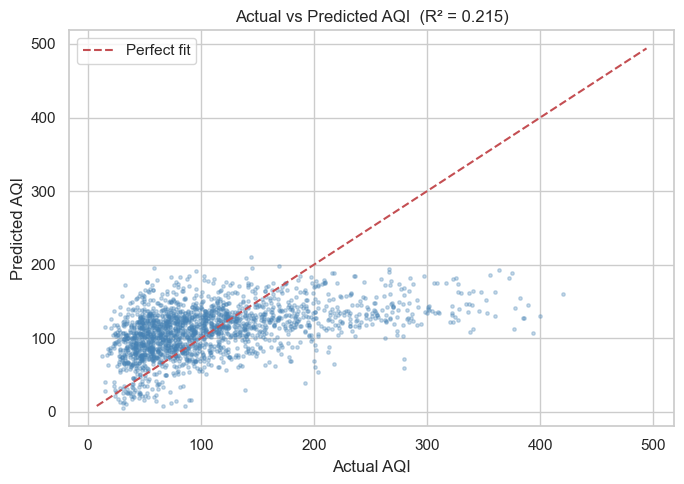

In [39]:
# Actual vs Predicted scatter plot
idx = np.random.choice(len(y_test_r), 2000, replace=False)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_r.values[idx], y_pred_lr[idx], alpha=0.3, s=6, color='steelblue')
mn, mx = y_test_r.min(), y_test_r.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
plt.title(f'Actual vs Predicted AQI  (R² = {r2:.3f})')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.legend()
plt.tight_layout()
plt.show()

### 10.2 Logistic Regression — Classification Metrics

- **Accuracy:** Overall % of correct predictions
- **Precision:** Of all predicted-polluted days, how many actually were polluted?
- **Recall:** Of all actually-polluted days, how many did the model catch?
- **F1-Score:** Harmonic mean of Precision and Recall — balanced metric

In [40]:
acc  = accuracy_score(y_test_c, y_pred_lg)
prec = precision_score(y_test_c, y_pred_lg)
rec  = recall_score(y_test_c, y_pred_lg)
f1   = f1_score(y_test_c, y_pred_lg)

print("Logistic Regression — Evaluation:")
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_lg, target_names=['Clean (0)', 'Polluted (1)']))

Logistic Regression — Evaluation:
  Accuracy  : 0.6890 (68.90%)
  Precision : 0.6596
  Recall    : 0.6222
  F1-Score  : 0.6404

Classification Report:
              precision    recall  f1-score   support

   Clean (0)       0.71      0.74      0.73     26174
Polluted (1)       0.66      0.62      0.64     20983

    accuracy                           0.69     47157
   macro avg       0.68      0.68      0.68     47157
weighted avg       0.69      0.69      0.69     47157



<Figure size 600x500 with 0 Axes>

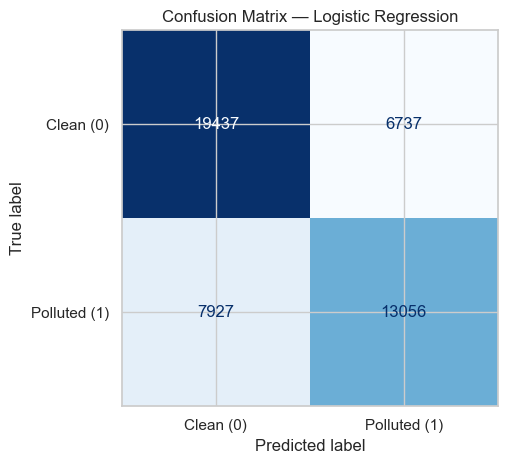

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_lg)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Clean (0)', 'Polluted (1)'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

---
## Summary

| Step | What was done |
|---|---|
| EDA | Explored 2,35,785 records across 32 states, 291 cities |
| Visualizations | Histogram, bar chart, box plot, heatmap, pair plot, line chart, recovery chart |
| Cleaning | Dropped `note` (100% null) and `unit` (constant), removed exact duplicates |
| Statistics | Shapiro-Wilk, t-test, Chi-squared, Poisson distribution |
| ML Model 1 | Linear Regression → predicts AQI value (R², MAE, RMSE) |
| ML Model 2 | Logistic Regression → classifies Clean vs Polluted (Accuracy, F1-Score) |
| Research Finding | Recovery Coefficient computed per state — most states pollute faster than they recover |

**Key Finding:** The t-test result and the Recovery Coefficient table together show whether Indian cities have an asymmetric pollution pattern — spiking faster than they recover.